In [ ]:
#####################################################
# Imports and Simulation IO
#####################################################
import os 
import numpy as np
from MDToolkit.data.objects import Topology, Frame, Simulation, LAMMPS_CustomDump_Reader
from MDToolkit.utils.structure_file_utils import create_elements_dictionary
from MDToolkit.analysis.diffusivity import compute_msd

filedir = "/media/jrjoseph/Elements/projects/training/water_box_ls6/"
filename = "water_box_nvt_prod_coarse.out"

filepath = os.path.join(filedir, filename)

type_mapping = {
    1 : "O",
    2 : "H",
}

topol = Topology(type_mapping, elements_dict = create_elements_dictionary())

reader = LAMMPS_CustomDump_Reader(filepath, topol)

simulation = Simulation(filepath, topol, LAMMPS_CustomDump_Reader)

In [2]:
#####################################################
# Plotting Functions
#####################################################

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_msd(
    msd_data,
    axes=["x", "y", "z", "sum"],
    show_std=True,
    std_label="±1σ",
    ax=None
):
    '''
    Plot mean MSD with optional standard deviation shading.
    '''

    if ax is None:
        fig, ax = plt.subplots()

    t = msd_data["t"]
    msd = msd_data["msd"]
    std = msd_data["std"]

    color_map = {
        "x": "C0",
        "y": "C1",
        "z": "C2",
        "sum": "C3"
    }

    label_map = {
        "x": "MSD$_x$",
        "y": "MSD$_y$",
        "z": "MSD$_z$",
        "sum": "Total MSD"
    }

    column_map = {
        "x": 0,
        "y": 1,
        "z": 2,
        "sum": 3
    }

    for axis in axes:

        idx = column_map[axis]
        color = color_map[axis]

        ax.plot(
            t,
            msd[:, idx],
            lw=2,
            color=color,
            label=label_map[axis]
        )

        if show_std:
            ax.fill_between(
                t,
                msd[:, idx] - std[:, idx],
                msd[:, idx] + std[:, idx],
                color=color,
                alpha=0.2
            )

    ax.set_xlabel("Time Step")
    ax.set_ylabel(r"MSD ($\mathrm{\AA^2}$)")

    handles, labels = ax.get_legend_handles_labels()

    if show_std:
        handles.append(
            Patch(facecolor="gray", alpha=0.2, label=std_label)
        )

    ax.legend(
        handles=handles,
        frameon=False,
        ncol=2,
        loc="best"
    )

    return ax

  0%|          | 0/10 [00:00<?, ?it/s]

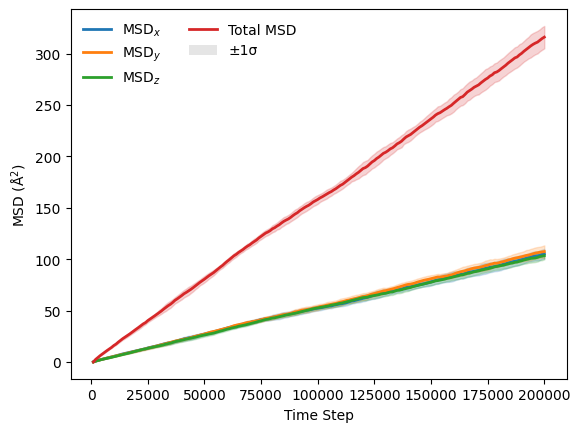

In [3]:
msd_data = compute_msd(simulation, n_averaging_blocks = 10)

plot_msd(msd_data)
plt.show()

In [6]:
# Diffusivity from MSD

coefficients, cov_matrix = np.polyfit(
    msd_data["t"],
    msd_data["msd"][:, 3],
    deg=1,
    cov=True
)

slope = coefficients[0]

# Standard deviation of the fitted slope
slope_std_dev = np.sqrt(cov_matrix[0, 0])

# Å²/fs -> m²/s
conversion = 1e15 / 1e20

D = slope * conversion / 6
D_std = slope_std_dev * conversion / 6

print(f"D (m²/s): {D}")
print(f"D std dev: {D_std}")

D (m²/s): 2.616049376782064e-09
D std dev: 2.9317278601347647e-12
